<a href="https://colab.research.google.com/github/sarahj150806-ctrl/Irrigation-Requirement-Prediction/blob/main/Sarah_J_(LD_1787379388295).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Irrigation Requirement Predictor

The Problem Statement

The aim of this project is to classify the irrigation requirement of an agricultural field as Low, Medium, or High using factors such as soil moisture, temperature, humidity, rainfall, crop type, and crop growth stage.

What I Have Done

I explored and cleaned the dataset, checked for missing values and duplicates, performed EDA, and split the data into training and testing sets. I applied preprocessing using StandardScaler and OneHotEncoder, trained a Logistic Regression model, evaluated it using classification metrics and a confusion matrix, saved the trained model, and created a Streamlit application for making irrigation predictions.

The Link
https://8501-m-s-kkb-usc1c1-3o19cal7yjmxc-c.us-central1-1.prod.colab.dev/#irrigation-requirement-predictor



In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akanshupoddar/predicting-irrigation-need")

print("Path to dataset files:", path)

100%|██████████| 31.9M/31.9M [00:00<00:00, 185MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/akanshupoddar/predicting-irrigation-need/versions/1


In [ ]:
import os

print(os.listdir(path))

['test.csv', 'train.csv']


In [ ]:
import pandas as pd

train_path = os.path.join(path, "train.csv")

df = pd.read_csv(train_path)

print(df.shape)
print(df.head())
print(df.columns.tolist())

(630000, 21)
   id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0   0     Loamy     4.92          32.58            1.01   
1   1      Clay     7.08          56.61            0.44   
2   2      Clay     5.69          27.71            0.81   
3   3     Sandy     5.65          13.32            1.33   
4   4      Clay     7.96          59.14            0.38   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                     3.05          15.01     50.61       725.99   
1                     2.00          22.92     67.86       985.66   
2                     2.83          26.97     92.22      2201.70   
3                     0.87          13.32     61.57      1357.33   
4                     0.96          20.22     91.11      1538.20   

   Sunlight_Hours  ...  Crop_Type Crop_Growth_Stage  Season Irrigation_Type  \
0            5.90  ...  Sugarcane            Sowing    Zaid            Drip   
1            6.98  ...      Wheat        Vegetative  Kharif      

In [ ]:
print("Shape:", df.shape)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nTarget Distribution")
print(df["Irrigation_Need"].value_counts())

print("\nTarget Percentage")
print(df["Irrigation_Need"].value_counts(normalize=True) * 100)

Shape: (630000, 21)

Data Types
id                           int64
Soil_Type                   object
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                   object
Crop_Growth_Stage           object
Season                      object
Irrigation_Type             object
Water_Source                object
Field_Area_hectare         float64
Mulching_Used               object
Previous_Irrigation_mm     float64
Region                      object
Irrigation_Need             object
dtype: object

Missing Values
id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0


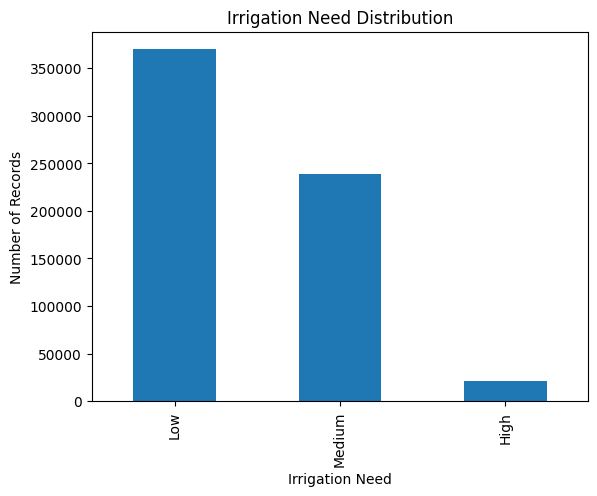

In [ ]:
import matplotlib.pyplot as plt

# 1. Target distribution
df["Irrigation_Need"].value_counts().plot(kind="bar")
plt.title("Irrigation Need Distribution")
plt.xlabel("Irrigation Need")
plt.ylabel("Number of Records")
plt.show()

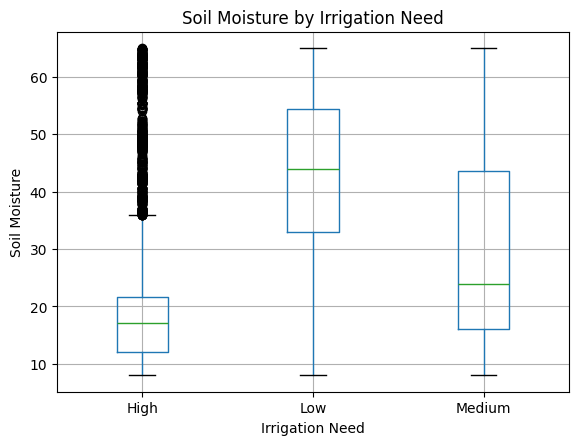

In [ ]:
# 2. Soil Moisture vs Irrigation Need
df.boxplot(column="Soil_Moisture", by="Irrigation_Need")
plt.title("Soil Moisture by Irrigation Need")
plt.suptitle("")
plt.xlabel("Irrigation Need")
plt.ylabel("Soil Moisture")
plt.show()

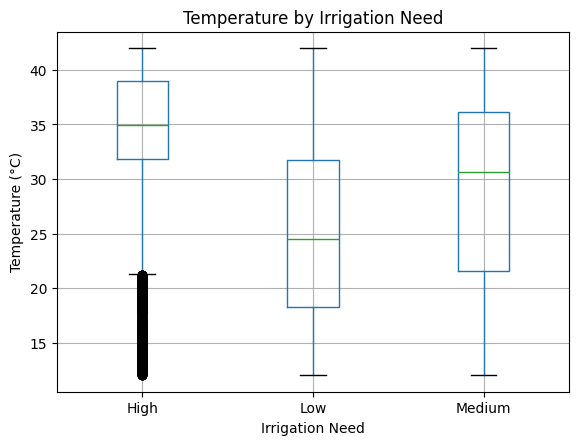

In [ ]:
# 3. Temperature vs Irrigation Need
df.boxplot(column="Temperature_C", by="Irrigation_Need")
plt.title("Temperature by Irrigation Need")
plt.suptitle("")
plt.xlabel("Irrigation Need")
plt.ylabel("Temperature (°C)")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['id', 'Irrigation_Need'])
y = df['Irrigation_Need']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (504000, 19)
X_test: (126000, 19)
y_train: (504000,)
y_test: (126000,)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical columns:")
print(list(categorical_cols))

print("\nNumerical columns:")
print(list(numerical_cols))

Categorical columns:
['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

Numerical columns:
['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']


In [ ]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

In [ ]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('logistic_regression', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [ ]:
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [ ]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print(y_pred[:10])

Predictions completed!
['Low' 'Medium' 'Medium' 'Low' 'Low' 'Low' 'Medium' 'Medium' 'Medium'
 'Medium']


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Accuracy : 0.8767
Precision: 0.8764
Recall   : 0.8767
F1-score : 0.8758


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.81      0.58      0.67      4202
         Low       0.91      0.91      0.91     73983
      Medium       0.83      0.85      0.84     47815

    accuracy                           0.88    126000
   macro avg       0.85      0.78      0.81    126000
weighted avg       0.88      0.88      0.88    126000



Confusion Matrix:
[[ 2431    18  1753]
 [    0 67465  6518]
 [  574  6676 40565]]


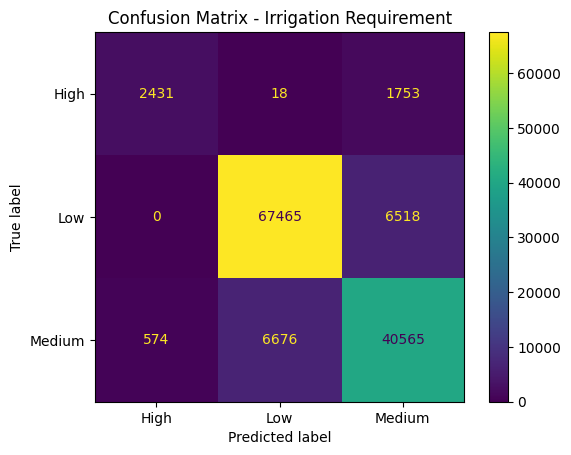

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Confusion Matrix - Irrigation Requirement")
plt.show()

In [ ]:
import joblib

joblib.dump(model, "irrigation_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

print(os.path.getsize("irrigation_model.pkl"), "bytes")

7665 bytes


In [ ]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


Soil_Type:
['Loamy' 'Clay' 'Sandy' 'Silt']

Crop_Type:
['Sugarcane' 'Wheat' 'Rice' 'Potato' 'Cotton' 'Maize']

Crop_Growth_Stage:
['Sowing' 'Vegetative' 'Flowering' 'Harvest']

Season:
['Zaid' 'Kharif' 'Rabi']

Irrigation_Type:
['Drip' 'Rainfed' 'Sprinkler' 'Canal']

Water_Source:
['Rainwater' 'River' 'Reservoir' 'Groundwater']

Mulching_Used:
['No' 'Yes']

Region:
['East' 'South' 'North' 'West' 'Central']


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!pip install streamlit

In [ ]:
!ls -lh app.py irrigation_model.pkl

ls: cannot access 'app.py': No such file or directory
-rw-r--r-- 1 root root 7.5K Sep 27 11:04 irrigation_model.pkl


In [103]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

model = joblib.load("irrigation_model.pkl")

st.set_page_config(
    page_title="Irrigation Requirement Predictor",
    page_icon="🌱"
)

st.title("🌱 Irrigation Requirement Predictor")
st.write("Enter the agricultural conditions to predict irrigation requirement.")

soil_type = st.selectbox(
    "Soil Type",
    ["Loamy", "Clay", "Sandy", "Silt"]
)

soil_ph = st.number_input("Soil pH", 0.0, 14.0, 7.0)

soil_moisture = st.number_input("Soil Moisture", 0.0, 100.0, 30.0)

organic_carbon = st.number_input("Organic Carbon", 0.0, 10.0, 1.0)

electrical_conductivity = st.number_input(
    "Electrical Conductivity", 0.0, 20.0, 2.0
)

temperature = st.number_input(
    "Temperature (°C)", -10.0, 60.0, 25.0
)

humidity = st.number_input(
    "Humidity", 0.0, 100.0, 60.0
)

rainfall = st.number_input(
    "Rainfall (mm)", 0.0, 5000.0, 500.0
)

sunlight = st.number_input(
    "Sunlight Hours", 0.0, 24.0, 6.0
)

wind_speed = st.number_input(
    "Wind Speed (km/h)", 0.0, 100.0, 10.0
)

crop_type = st.selectbox(
    "Crop Type",
    ["Sugarcane", "Wheat", "Rice", "Potato", "Cotton", "Maize"]
)

crop_stage = st.selectbox(
    "Crop Growth Stage",
    ["Sowing", "Vegetative", "Flowering", "Harvest"]
)

season = st.selectbox(
    "Season",
    ["Zaid", "Kharif", "Rabi"]
)

irrigation_type = st.selectbox(
    "Irrigation Type",
    ["Drip", "Rainfed", "Sprinkler", "Canal"]
)

water_source = st.selectbox(
    "Water Source",
    ["Rainwater", "River", "Reservoir", "Groundwater"]
)

field_area = st.number_input(
    "Field Area (hectare)", 0.0, 1000.0, 1.0
)

mulching = st.selectbox(
    "Mulching Used",
    ["No", "Yes"]
)

previous_irrigation = st.number_input(
    "Previous Irrigation (mm)", 0.0, 500.0, 50.0
)

region = st.selectbox(
    "Region",
    ["East", "South", "North", "West", "Central"]
)

if st.button("🌱 Predict Irrigation Requirement"):

    input_data = pd.DataFrame([{
        "Soil_Type": soil_type,
        "Soil_pH": soil_ph,
        "Soil_Moisture": soil_moisture,
        "Organic_Carbon": organic_carbon,
        "Electrical_Conductivity": electrical_conductivity,
        "Temperature_C": temperature,
        "Humidity": humidity,
        "Rainfall_mm": rainfall,
        "Sunlight_Hours": sunlight,
        "Wind_Speed_kmh": wind_speed,
        "Crop_Type": crop_type,
        "Crop_Growth_Stage": crop_stage,
        "Season": season,
        "Irrigation_Type": irrigation_type,
        "Water_Source": water_source,
        "Field_Area_hectare": field_area,
        "Mulching_Used": mulching,
        "Previous_Irrigation_mm": previous_irrigation,
        "Region": region
    }])

    prediction = model.predict(input_data)[0]

    st.success(
        f"🌱 Predicted Irrigation Requirement: **{prediction}**"
    )

Overwriting app.py


In [104]:
!ls -lh app.py irrigation_model.pkl

-rw-r--r-- 1 root root 2.8K Sep 27 13:39 app.py
-rw-r--r-- 1 root root 7.5K Sep 27 12:48 irrigation_model.pkl


In [111]:
!streamlit run app.py --server.headless true --server.address 0.0.0.0 --server.port 8501 --server.enableCORS false --server.enableXsrfProtection false > streamlit.log 2>&1 &

In [112]:
!cat streamlit.log



2026-09-27 13:42:30.076 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.225.205.208:8501



In [113]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

https://8501-m-s-kkb-usc1c1-3o19cal7yjmxc-c.us-central1-1.prod.colab.dev
